# Seguimiento mediante diferencia de imágenes

Este notebook muestra la implementación básica del método de diferencia de imágenes.

El método compara fotogramas consecutivos para detectar regiones de la imagen que cambian con el tiempo. En este proyecto, esta idea se aplica a una secuencia completa de vídeo para estimar la posición de la región móvil principal mediante su centroide.

Este notebook se utiliza como una demostración inicial del método. Los experimentos completos con todos los escenarios sintéticos y reales se ejecutan desde los scripts de la carpeta `src/`.

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


project_dir = Path(r"C:\Users\34689\Desktop\Glole\U\masterus\percep")

video_path = project_dir / "data" / "synthetic_videos" / "synthetic_clean_1.mp4"

output_video_path = project_dir / "outputs" / "processed_videos" / "synthetic" / "lucas_kanade_synthetic_clean_1_demo.mp4"
output_csv_path = project_dir / "outputs" / "plots" / "synthetic" / "lucas_kanade_synthetic_clean_1_demo.csv"
summary_csv_path = project_dir / "outputs" / "plots" / "synthetic" / "lucas_kanade_synthetic_clean_1_summary_demo.csv"

output_video_path.parent.mkdir(parents=True, exist_ok=True)
output_csv_path.parent.mkdir(parents=True, exist_ok=True)

print("Directorio del proyecto:", project_dir)
print("Ruta del vídeo:", video_path)
print("Existe el vídeo:", video_path.exists())


Directorio del proyecto: C:\Users\34689\Desktop\Glole\U\masterus\percep
Ruta del vídeo: C:\Users\34689\Desktop\Glole\U\masterus\percep\data\synthetic_videos\synthetic_clean_1.mp4
Existe el vídeo: True


In [4]:
cap = cv2.VideoCapture(str(video_path))

print("OpenCV can open video:", cap.isOpened())

if cap.isOpened():
    print("FPS:", cap.get(cv2.CAP_PROP_FPS))
    print("Frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    print("Width:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
    print("Height:", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

cap.release()

OpenCV can open video: True
FPS: 30.0
Frames: 180
Width: 640
Height: 360


In [5]:
def track_motion_with_lucas_kanade(
    input_video_path: Path,
    output_video_path: Path,
):
    """
    Sigue puntos característicos usando el método de flujo óptico Lucas-Kanade.
    """

    cap = cv2.VideoCapture(str(input_video_path))

    if not cap.isOpened():
        raise RuntimeError("No se pudo abrir el vídeo de entrada")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_video_path), fourcc, fps, (width, height))

    ret, old_frame = cap.read()

    if not ret:
        raise RuntimeError("No se pudo leer el primer fotograma")

    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

    feature_params = dict(
        maxCorners=50,
        qualityLevel=0.05,
        minDistance=15,
        blockSize=7
    )

    lk_params = dict(
        winSize=(21, 21),
        maxLevel=3,
        criteria=(
            cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
            20,
            0.03
        )
    )

    p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

    tracked_data = []
    frame_index = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        output_frame = frame.copy()

        if p0 is None or len(p0) < 5:
            p0 = cv2.goodFeaturesToTrack(frame_gray, mask=None, **feature_params)

            cv2.putText(
                output_frame,
                f"Fotograma: {frame_index} | Puntos LK: 0",
                (20, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),
                2
            )

            cv2.putText(
                output_frame,
                "Redetectando puntos caracteristicos",
                (20, 60),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),
                2
            )

            writer.write(output_frame)

            old_gray = frame_gray.copy()
            frame_index += 1
            continue

        p1, status, error = cv2.calcOpticalFlowPyrLK(
            old_gray,
            frame_gray,
            p0,
            None,
            **lk_params
        )

        if p1 is None or status is None:
            p0 = cv2.goodFeaturesToTrack(frame_gray, mask=None, **feature_params)

            cv2.putText(
                output_frame,
                f"Fotograma: {frame_index} | Puntos LK: 0",
                (20, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),
                2
            )

            cv2.putText(
                output_frame,
                "Flujo perdido, reiniciando puntos",
                (20, 60),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),
                2
            )

            writer.write(output_frame)

            old_gray = frame_gray.copy()
            frame_index += 1
            continue

        good_new = p1[status == 1]
        good_old = p0[status == 1]

        displacements = []

        for new_point, old_point in zip(good_new, good_old):
            x_new, y_new = new_point.ravel()
            x_old, y_old = old_point.ravel()

            dx = x_new - x_old
            dy = y_new - y_old
            displacement = np.sqrt(dx**2 + dy**2)

            displacements.append(displacement)

            tracked_data.append({
                "frame": frame_index,
                "x_old": x_old,
                "y_old": y_old,
                "x_new": x_new,
                "y_new": y_new,
                "dx": dx,
                "dy": dy,
                "displacement": displacement
            })

            x_new_i, y_new_i = int(x_new), int(y_new)
            x_old_i, y_old_i = int(x_old), int(y_old)

            cv2.line(
                output_frame,
                (x_old_i, y_old_i),
                (x_new_i, y_new_i),
                (255, 0, 0),
                2
            )

            cv2.circle(
                output_frame,
                (x_new_i, y_new_i),
                4,
                (0, 0, 255),
                -1
            )

        mean_displacement = np.mean(displacements) if len(displacements) > 0 else 0

        cv2.putText(
            output_frame,
            f"Fotograma: {frame_index} | Puntos LK: {len(good_new)}",
            (20, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        cv2.putText(
            output_frame,
            f"Desplazamiento medio: {mean_displacement:.2f} px/fotograma",
            (20, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        writer.write(output_frame)

        old_gray = frame_gray.copy()

        if len(good_new) < 5:
            p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
        else:
            p0 = good_new.reshape(-1, 1, 2)

        frame_index += 1

    cap.release()
    writer.release()

    tracked_df = pd.DataFrame(tracked_data)

    return tracked_df

In [6]:
tracked_df = track_motion_with_lucas_kanade(
    input_video_path=video_path,
    output_video_path=output_video_path
)

tracked_df.to_csv(output_csv_path, index=False)

print("Vídeo Lucas-Kanade guardado en:", output_video_path)
print("Puntos seguidos guardados en:", output_csv_path)
print("Número de registros de puntos:", len(tracked_df))

tracked_df.head()

Vídeo Lucas-Kanade guardado en: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\processed_videos\synthetic\lucas_kanade_synthetic_clean_1_demo.mp4
Puntos seguidos guardados en: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\lucas_kanade_synthetic_clean_1_demo.csv
Número de registros de puntos: 1432


,frame,x_old,y_old,x_new,y_new,dx,dy,displacement
0,0,82.0,176.0,84.000648,184.999741,2.000648,8.999741,9.219432
1,0,38.0,176.0,39.998360,184.998505,1.998360,8.998505,9.217729
2,0,56.0,202.0,58.000099,210.999283,2.000099,8.999283,9.218865
3,0,56.0,158.0,57.999992,167.000214,1.999992,9.000214,9.219751
4,0,53.0,180.0,54.999966,188.999908,1.999966,8.999908,9.219448


In [7]:
lk_summary = tracked_df.groupby("frame").agg(
    mean_x=("x_new", "mean"),
    mean_y=("y_new", "mean"),
    mean_dx=("dx", "mean"),
    mean_dy=("dy", "mean"),
    mean_displacement=("displacement", "mean"),
    num_points=("displacement", "count")
).reset_index()

lk_summary.to_csv(summary_csv_path, index=False)

print("Resumen Lucas-Kanade guardado en:", summary_csv_path)
lk_summary.head()

Resumen Lucas-Kanade guardado en: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\lucas_kanade_synthetic_clean_1_summary_demo.csv


,frame,mean_x,mean_y,mean_dx,mean_dy,mean_displacement,num_points
0,0,60.875057,189.624725,2.000058,8.999729,9.219293,8
1,1,63.874870,197.625381,2.999811,8.000647,8.544542,8
2,2,66.875351,206.626740,3.000485,9.001366,9.488282,8
3,3,69.875374,214.626785,3.000019,8.000048,8.544055,8
4,4,72.875313,222.626526,2.999939,7.999739,8.543737,8


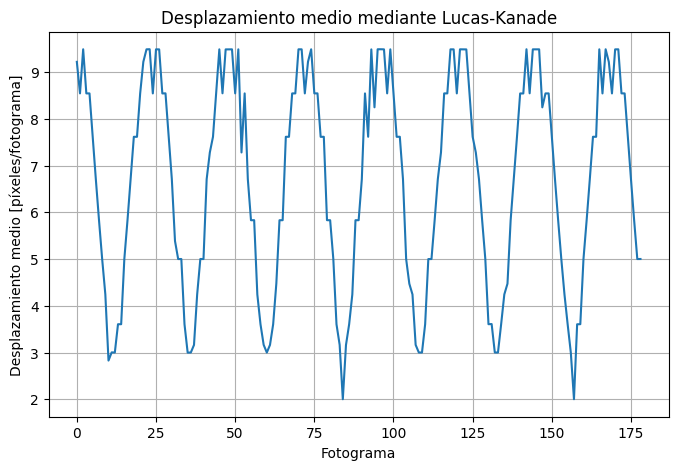

Gráfica guardada en: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\lucas_kanade_mean_displacement_demo.png


In [8]:
displacement_plot_path = project_dir / "outputs" / "plots" / "synthetic" / "lucas_kanade_mean_displacement_demo.png"

plt.figure(figsize=(8, 5))
plt.plot(lk_summary["frame"], lk_summary["mean_displacement"])
plt.xlabel("Fotograma")
plt.ylabel("Desplazamiento medio [píxeles/fotograma]")
plt.title("Desplazamiento medio mediante Lucas-Kanade")
plt.grid(True)
plt.savefig(displacement_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", displacement_plot_path)

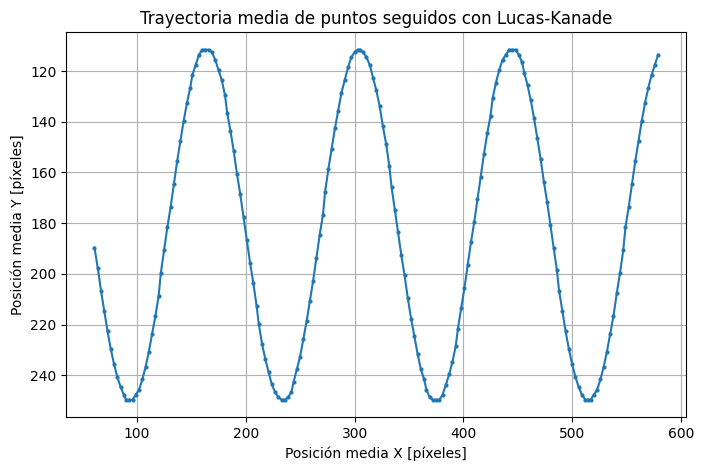

Gráfica guardada en: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\lucas_kanade_mean_trajectory_demo.png


In [9]:
lk_trajectory_plot_path = project_dir / "outputs" / "plots" / "synthetic" / "lucas_kanade_mean_trajectory_demo.png"

plt.figure(figsize=(8, 5))
plt.plot(lk_summary["mean_x"], lk_summary["mean_y"], marker="o", markersize=2)
plt.gca().invert_yaxis()
plt.xlabel("Posición media X [píxeles]")
plt.ylabel("Posición media Y [píxeles]")
plt.title("Trayectoria media de puntos seguidos con Lucas-Kanade")
plt.grid(True)
plt.savefig(lk_trajectory_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", lk_trajectory_plot_path)